In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

In [52]:
df = pd.read_csv('UCI_Credit_Card.csv')

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [54]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


# Data Preprocessing

In [55]:
df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)

In [56]:
df.drop('ID', axis=1, inplace=True)

In [57]:
df['EDUCATION'].value_counts()

,count
EDUCATION,
2,14030
1,10585
3,4917
5,280
4,123
6,51
0,14


In [58]:
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)

In [59]:
df['MARRIAGE'].value_counts()

,count
MARRIAGE,
2,15964
1,13659
3,323
0,54


In [60]:
df.loc[df['MARRIAGE'] == 0, 'MARRIAGE'] = 3

In [61]:
bill_cols=['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_cols=['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
delay_cols=['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

In [62]:
df['AVG_BILL'] = df[bill_cols].mean(axis=1)
df['AVG_PAYMENT'] = df[pay_cols].mean(axis=1)
df['PAY_BILL_RATIO'] = df['AVG_PAYMENT'] / (df['AVG_BILL'].abs() + 1)

In [63]:
df['DELAY_SCORE']=df[delay_cols].sum(axis=1)

In [64]:
for col in ['LIMIT_BAL', 'AVG_BILL', 'AVG_PAYMENT'] + bill_cols + pay_cols:
    df[col] = np.log1p(df[col].clip(lower=0))

In [65]:
pd.set_option('display.max_columns',None)

In [66]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default,AVG_BILL,AVG_PAYMENT,PAY_BILL_RATIO,DELAY_SCORE
0,9.903538,2,2,1,24,2,2,-1,-1,-2,-2,8.272315,8.040125,6.536692,0.000000,0.000000,0.000000,0.000000,6.536692,0.000000,0.000000,0.000000,0.000000,1,7.158514,4.752152,0.089364,-2
1,11.695255,2,2,2,26,-1,2,0,0,0,2,7.894691,7.453562,7.894691,8.093462,8.147867,8.090096,0.000000,6.908755,6.908755,6.908755,0.000000,7.601402,1,7.954080,6.726633,0.292689,3
2,11.407576,2,2,2,34,0,0,0,0,0,0,10.283293,9.548811,9.514880,9.570250,9.612400,9.651816,7.325808,7.313887,6.908755,6.908755,6.908755,8.517393,0,9.737620,7.516071,0.108382,0
3,10.819798,2,2,1,37,0,0,0,0,0,0,10.757711,10.783819,10.805517,10.251147,10.273671,10.293771,7.601402,7.610853,7.090910,7.003974,6.975414,6.908755,0,10.559884,7.243513,0.036258,0
4,10.819798,1,2,1,57,-1,0,-1,0,0,0,9.061608,8.643121,10.486708,9.949464,9.859901,9.859118,7.601402,10.510041,9.210440,9.105091,6.536692,6.522093,0,9.810504,9.194465,0.540025,-2


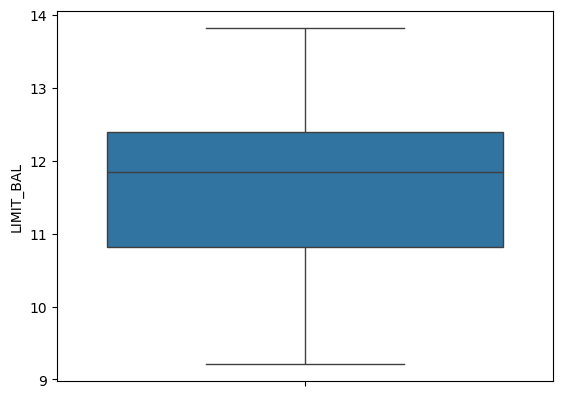

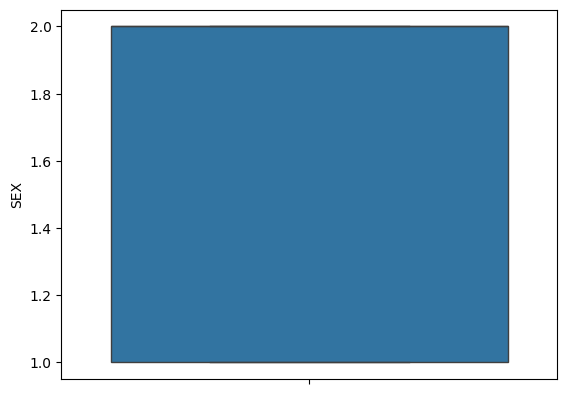

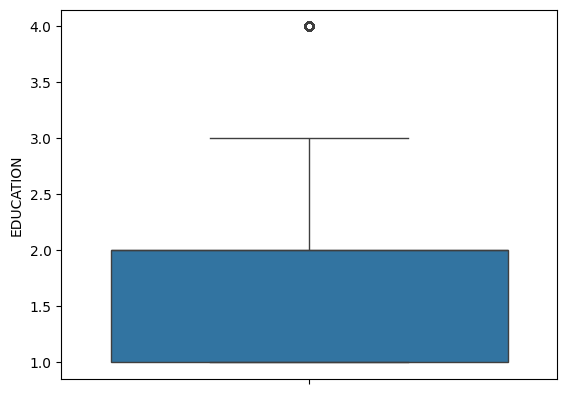

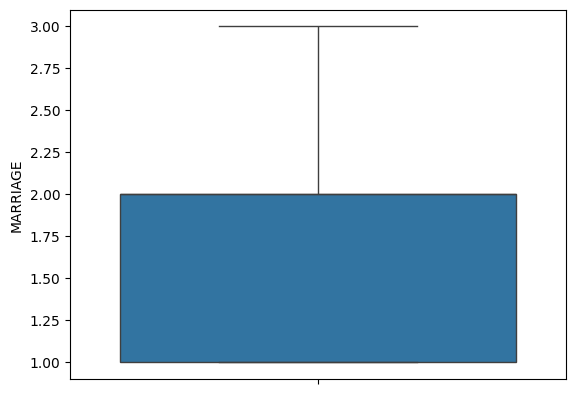

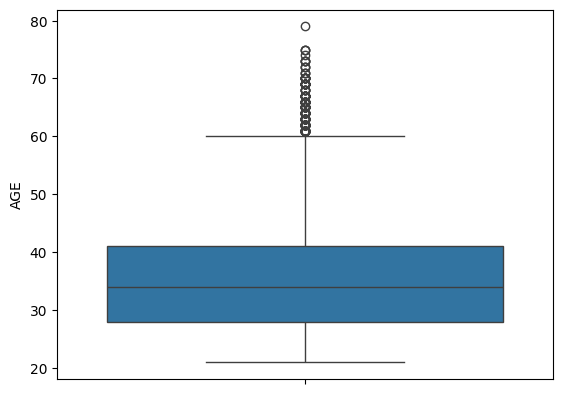

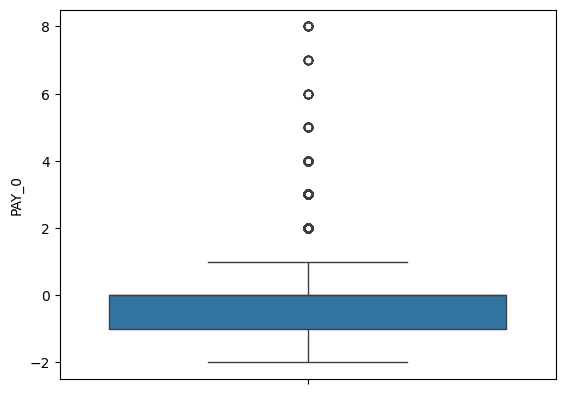

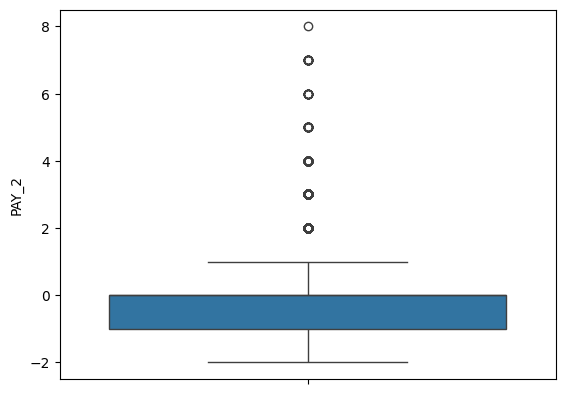

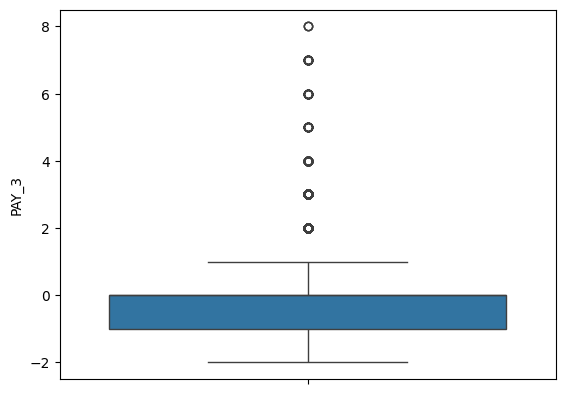

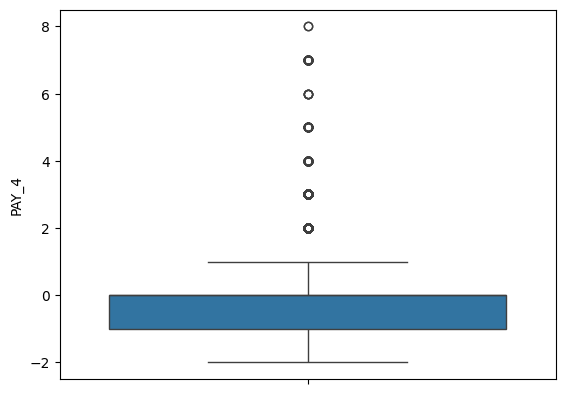

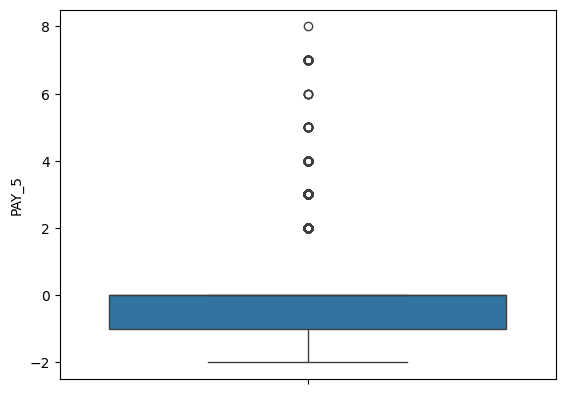

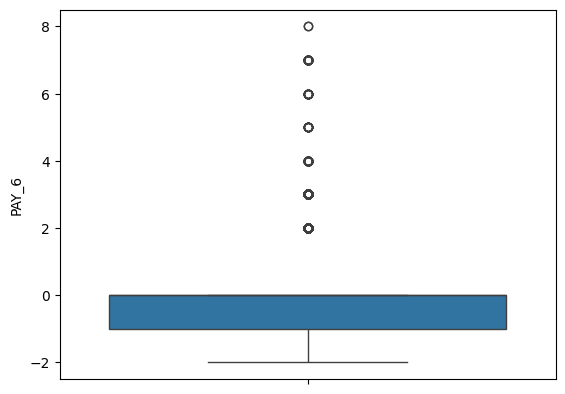

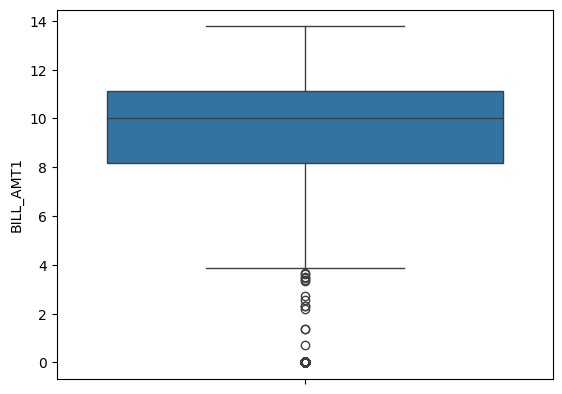

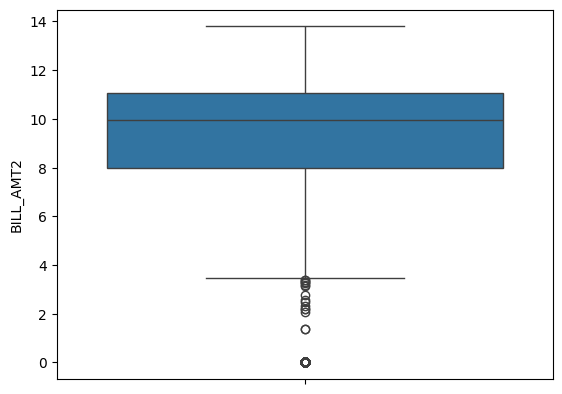

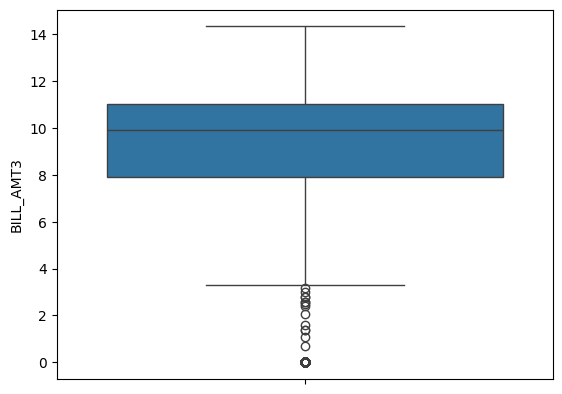

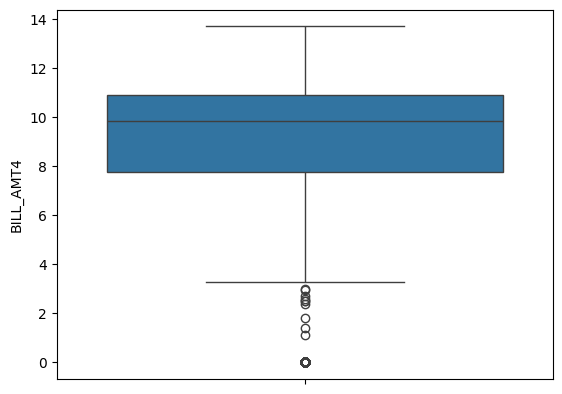

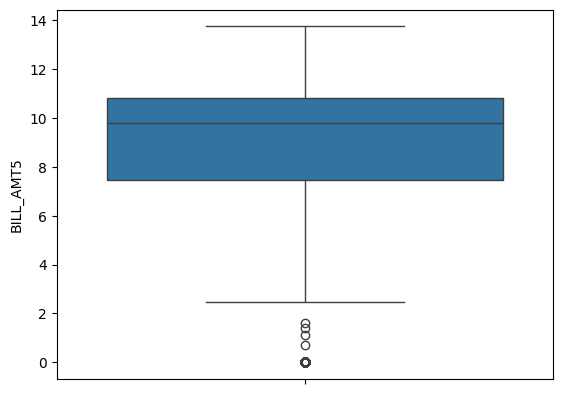

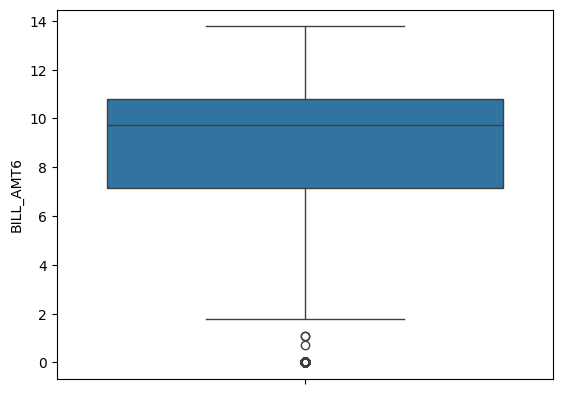

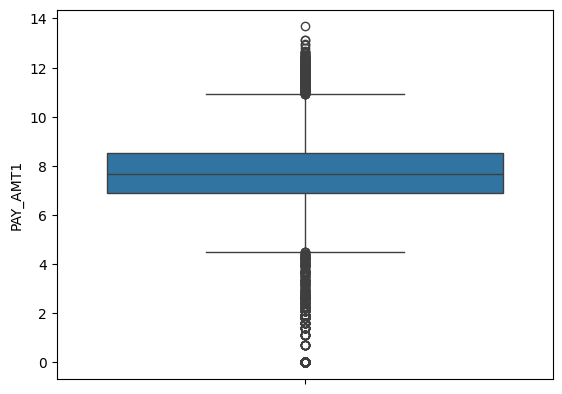

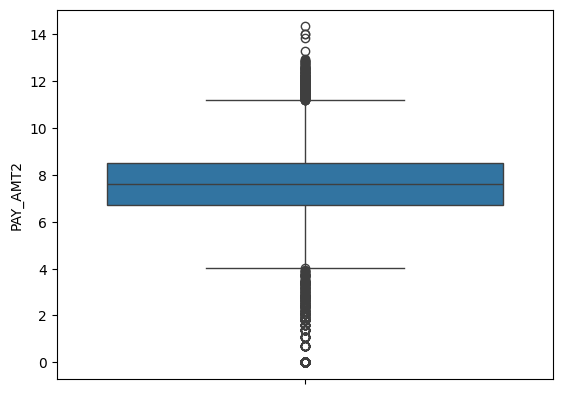

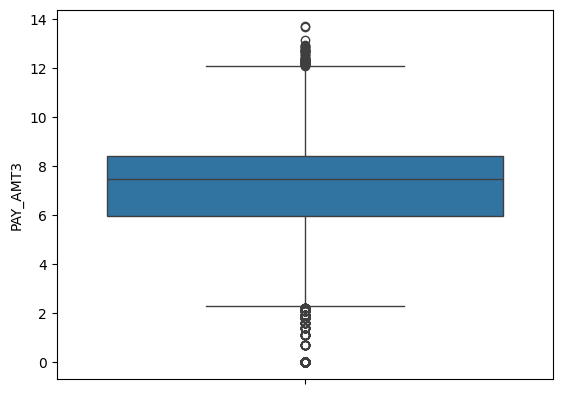

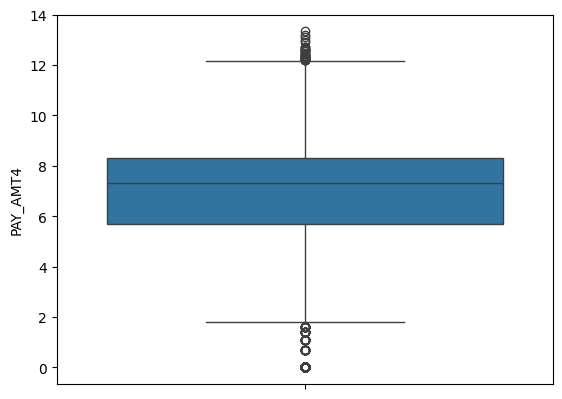

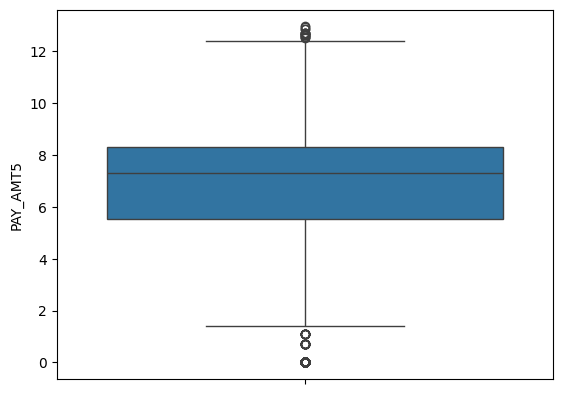

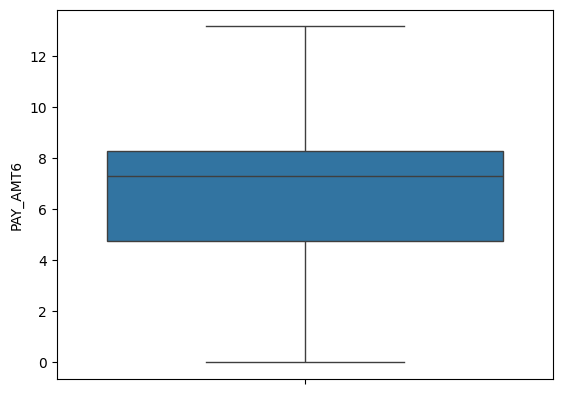

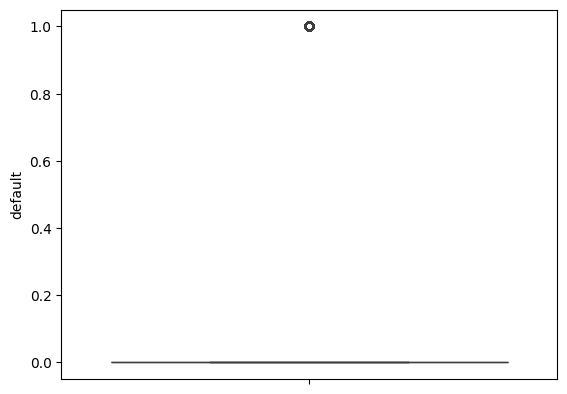

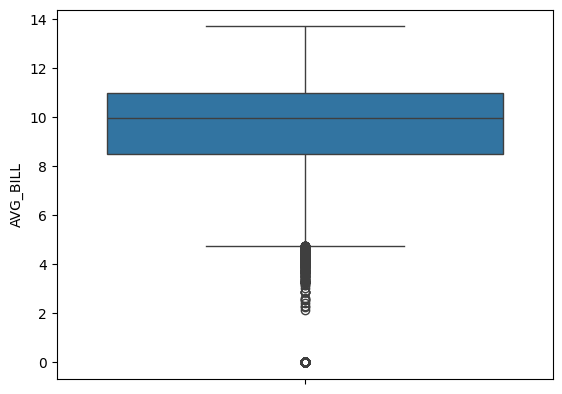

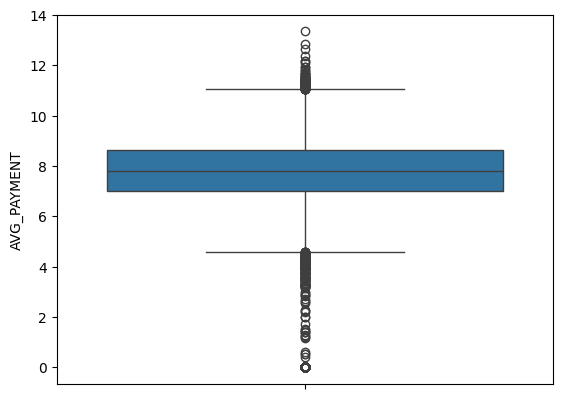

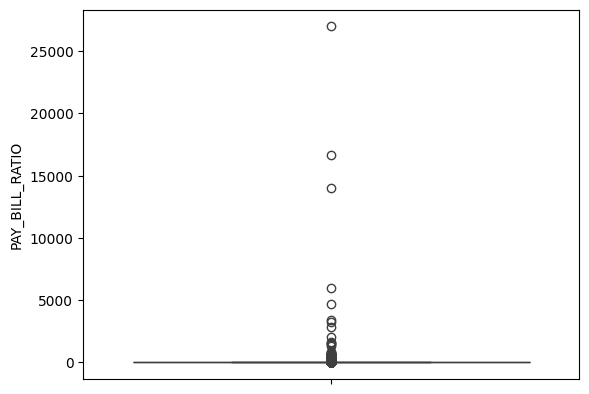

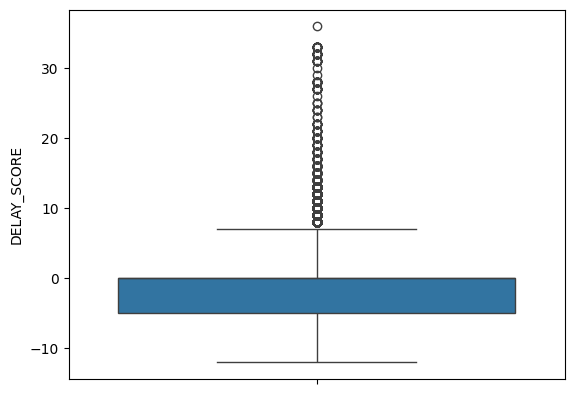

In [67]:
#identifying outliers
for i in df.columns:
  sns.boxplot(df[i])
  plt.show()

<Axes: >

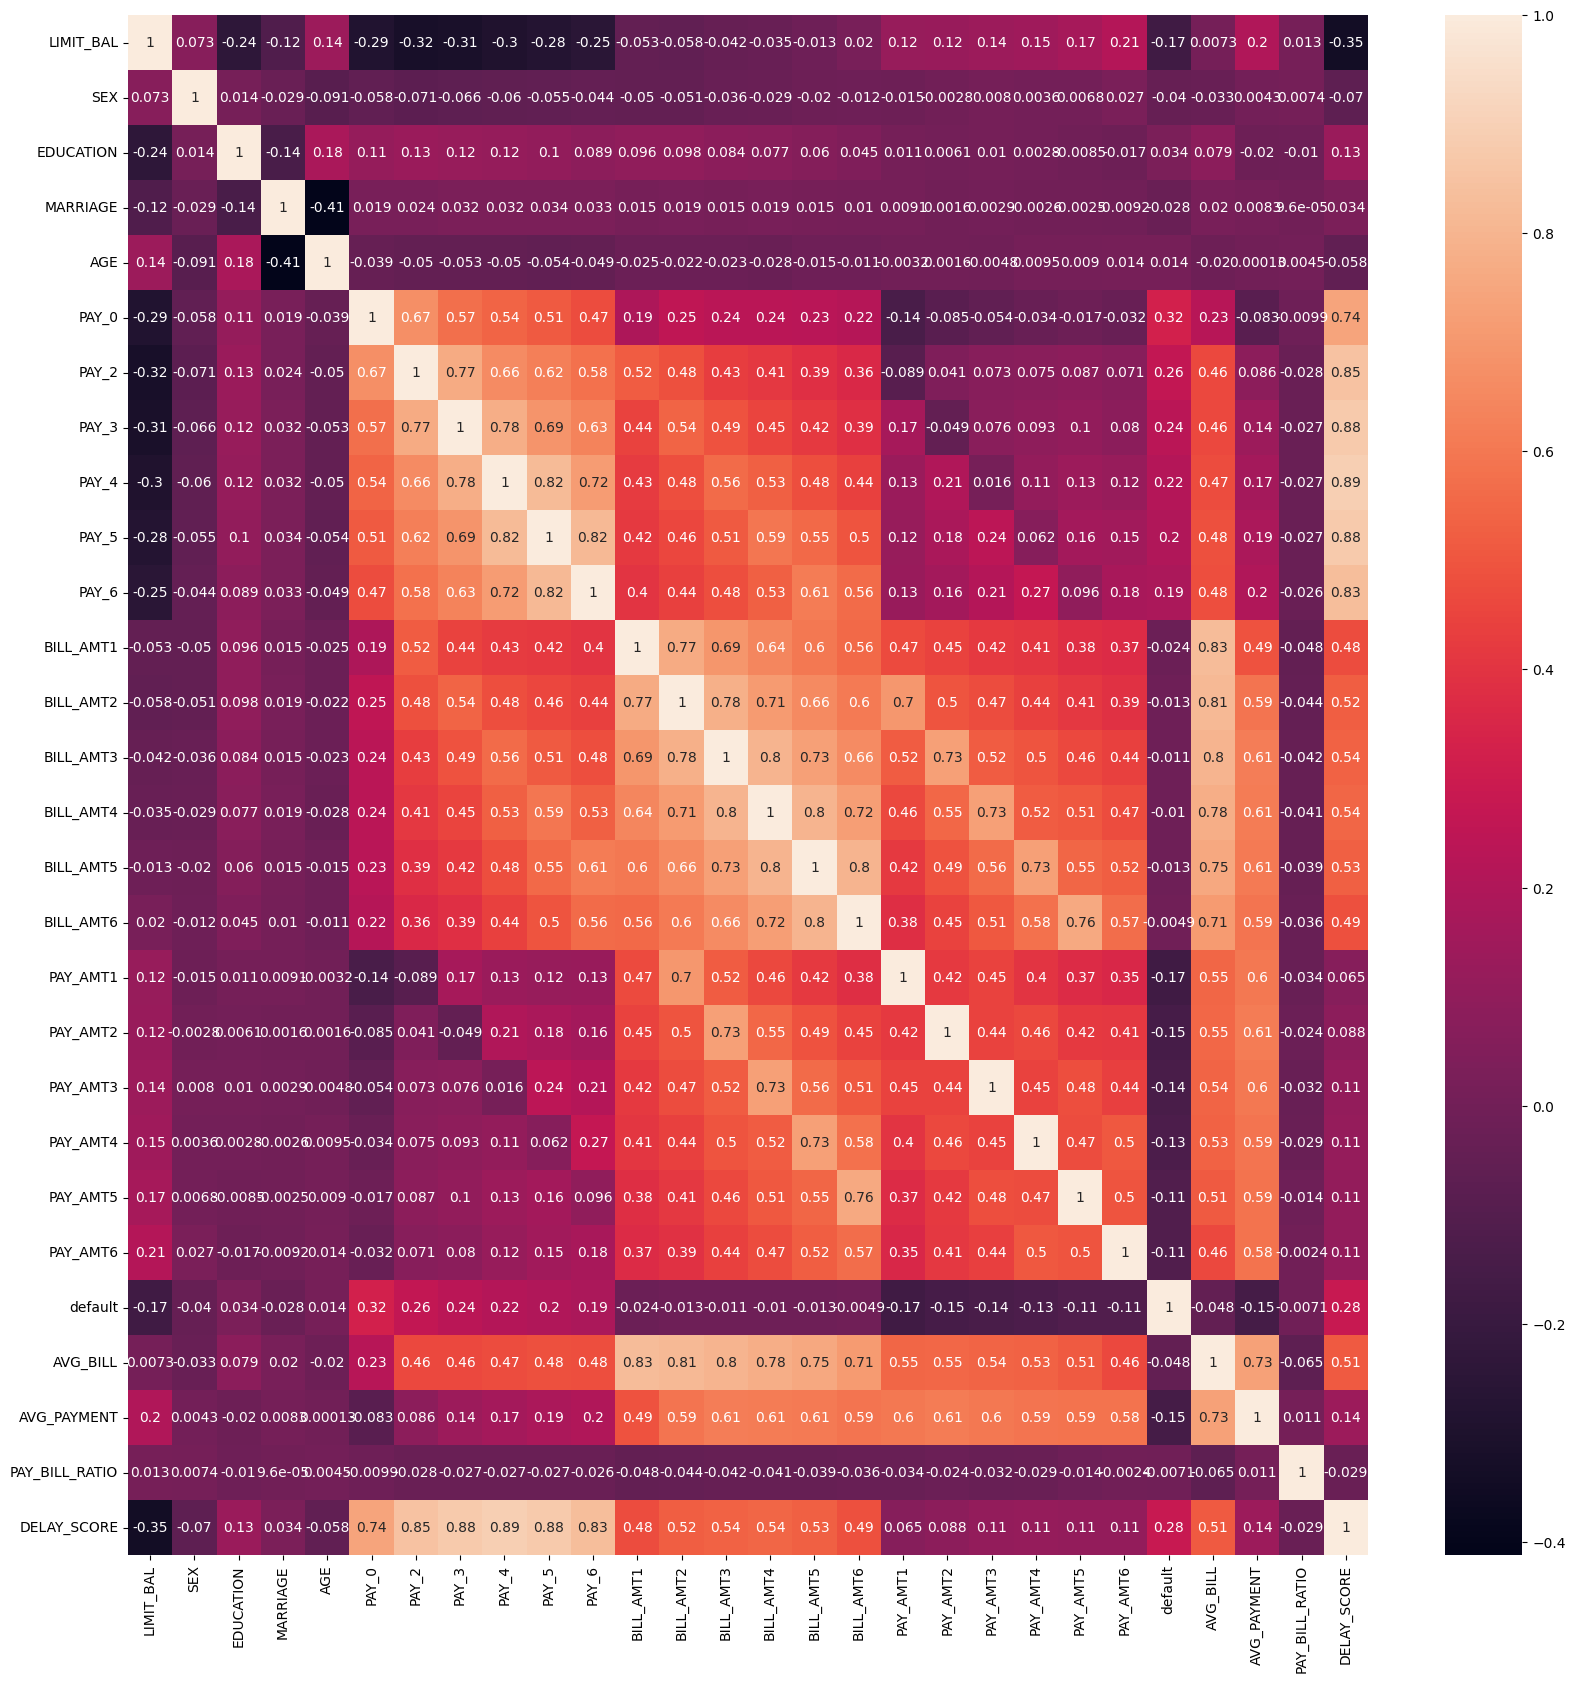

In [68]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(),annot=True)


In [69]:
X = df.drop(columns=['default'])

In [70]:
y=df['default']

In [71]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [72]:
scaler=RobustScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [73]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

In [74]:
gb = GradientBoostingClassifier()
gb.fit(X_train_scaled, y_train,sample_weight=sample_weights)

GradientBoostingClassifier()

In [75]:
y_prob = gb.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob > 0.68).astype(int)

In [76]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.8163
ROC-AUC  : 0.7787
              precision    recall  f1-score   support

  No Default       0.86      0.92      0.89      4673
     Default       0.61      0.46      0.52      1327

    accuracy                           0.82      6000
   macro avg       0.74      0.69      0.70      6000
weighted avg       0.80      0.82      0.81      6000

Confusion Matrix:
[[4294  379]
 [ 723  604]]


In [77]:
import pickle

In [80]:
with open('scaler.pkl','wb') as f:
  pickle.dump(scaler,f)

In [79]:
with open('model.pkl','wb') as f:
  pickle.dump(gb,f)